## Hyperparameter: Image Resolution
- Can be adjusted with the IMG_SIZE variable

-> Chose

IMG_SIZE_1 = 64 (original)

IMG_SIZE_2 = 128

IMG_SIZE_3 = 32

IMG_SIZE_4 = 16

- created 4 copies of the notebook to train the 4 models, then then they are imported here

## Assumptions:
- Prediction accuracy will be the highest with medium-resolution images like the original image size of 64 we had for exercises. If the resolution is too low, the gestures can't be recognized anymore and if the resolution is too high, there will be too many distracting details interfering with prediction accuracy.
- Inference time for predictions will be growing with the image resolution, because with a higher resolution we have more pixels to go through and that takes more time.

In [80]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import pickle #to load history log

# import things from keras:
# sequential model
import keras.models

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## load models trained with different image resolutions:

In [ ]:
model_1 = keras.models.load_model("gesture_recognition_1.keras")
model_2 = keras.models.load_model("gesture_recognition_2.keras")
model_3 = keras.models.load_model("gesture_recognition_3.keras")
model_4 = keras.models.load_model("gesture_recognition_4.keras")

## Inference time for predictions

From the execution time of the training cell and the times for each epoch, I get the following values for each of the 4 Models:

Model 1 (image size 64): 
- 2m 17.4s total
- 8 - 15s per Epoch
- 124 - 234ms per Step

Model 2 (image size 128): 
- 12m 8.5s total
- 28 - 65s per Epoch
- 429 - 749ms per Step

Model 3 (image size 32): 
- 2m 12.5s total
- 4 - 9s per Epoch
- 58 - 139ms per Step

Model 4 (image size 16): 
- 37s total
- 1 - 4s per Epoch
- 11 - 39ms per Step

with the batch size of 8 used, we can roughly calculate the min and max inference times for predictions during training:

Model 1: 15.5ms, 29.25ms

Model 2: 53.625ms, 93.625ms

Model 3: 7.25ms, 17.375ms

Model 4: 1.375ms, 4.875ms


In [99]:
min_1 = 15.5
max_1 = 29.25
min_2 = 53.625
max_2 = 93.625
min_3 = 7.25
max_3 = 17.375
min_4 = 1.375
max_4 = 4.875

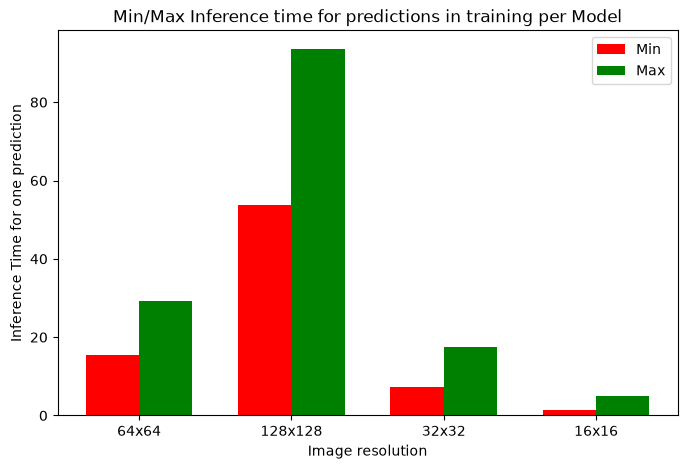

In [101]:
#plot min/max inference time for each image resolution
labels = ["64x64", "128x128", "32x32", "16x16"]

min_vals = [min_1, min_2, min_3, min_4]
max_vals = [max_1, max_2, max_3, max_4]

x = np.arange(4)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, min_vals, width, label="Min", color="red")
plt.bar(x + width/2, max_vals, width, label="Max", color="green")

plt.xlabel("Image resolution")
plt.ylabel("Inference Time for one prediction")
plt.title("Min/Max Inference time for predictions in training per Model")
plt.xticks(x, labels)
plt.legend()

plt.show()

## Prediction Accuracy in Training

In [82]:
#load training history
with open("history_1.pkl", "rb") as f:
    history_1 = pickle.load(f)
with open("history_2.pkl", "rb") as f:
    history_2 = pickle.load(f)
with open("history_3.pkl", "rb") as f:
    history_3 = pickle.load(f)
with open("history_4.pkl", "rb") as f:
    history_4 = pickle.load(f)

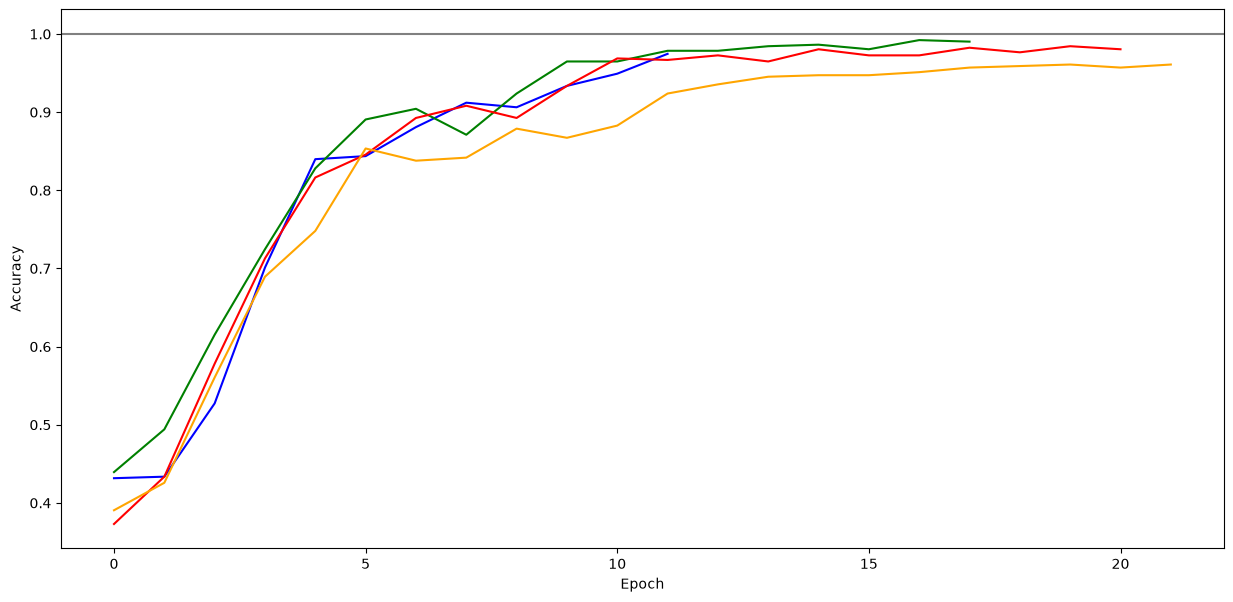

In [92]:
#plot training accuracy
accuracy_1 = history_1['accuracy']
accuracy_2 = history_2['accuracy']
accuracy_3 = history_3['accuracy']
accuracy_4 = history_4['accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')

ax.axhline(1, color='gray')

plt.plot(accuracy_1, color='blue')
plt.plot(accuracy_2, color='green')
plt.plot(accuracy_3, color='red')
plt.plot(accuracy_4, color='orange')

As we can see from the plot, the accuracy gain with each epoch is quite similar with different image resolutions, along with the achieved final accuracies. Also, there is a linear correlation between image resolution and number of epochs in training, meaning higher resolution resulted in less epochs in training. However, as we could see from the numbers earlier, the epochs themselves took significantly longer for images with a higher resolution.

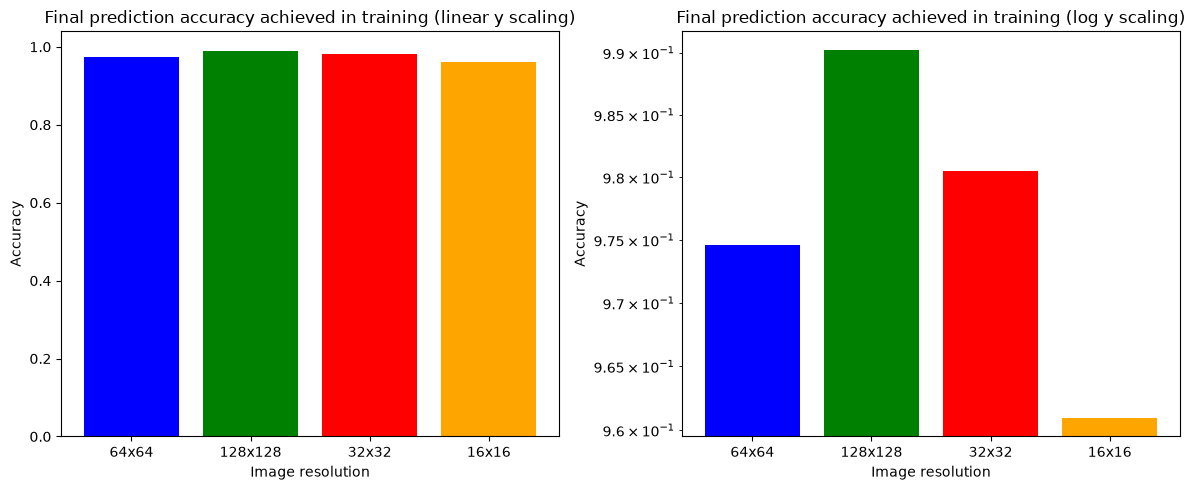

In [103]:
labels = ["64x64", "128x128", "32x32", "16x16"]
accuracies = [history_1["accuracy"][-1], history_2["accuracy"][-1], history_3["accuracy"][-1], history_4["accuracy"][-1],]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(labels, accuracies, color=["blue", "green", "red", "orange"])
ax1.set_title("Final prediction accuracy achieved in training (linear y scaling)")
ax1.set_xlabel("Image resolution")
ax1.set_ylabel("Accuracy")

ax2.bar(labels, accuracies, color=["blue", "green", "red", "orange"])
ax2.set_title("Final prediction accuracy achieved in training (log y scaling)")
ax2.set_xlabel("Image resolution")
ax2.set_ylabel("Accuracy")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

As we can see from these plots, the final prediction accuracy in training is quite similar in training. However, if we look a bit closer with log scaling on the y axis, we can see that significantly higher image resolution correlates with significantly higher accuracy (difference between 128x128). However, in middle area of resolutions tested, we can see quite the opposite: The 32x32 images achieved slightly higher accuracy than the 64x64 images.